<a href="https://colab.research.google.com/github/doney25/CaseStudy/blob/main/kaggle_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
train=pd.read_csv('/content/train.csv')
test=pd.read_csv('/content/test.csv')

In [35]:
train.shape

(94, 14)

In [36]:
test.shape

(41, 13)

In [37]:
train.head(10)

,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,H,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.20,208.40,2.38
1,A68_2016,H,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.20,204.40,2.14
2,E55_2015,H,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.20,210.40,2.50
3,7C7_2016,M,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.60,215.20,2.83
4,2C0_2018,H,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.70,207.40,2.73
5,A57_2016,H,175.14,107.89,80.96,50.97,32.20,25.83,92.07,51.7,97.0,106.00,212.00,2.21
6,5C0_2017,M,180.53,113.10,84.50,52.70,34.00,28.10,95.10,52.1,94.4,103.70,207.40,3.03
7,1J3_2015,H,168.06,104.55,78.86,54.50,29.34,23.89,84.41,50.5,94.5,99.77,199.54,2.20
8,4A3_2016,M,188.66,116.32,85.55,55.52,32.79,25.69,93.33,52.0,98.3,107.50,215.00,2.77
9,H58_2016,M,182.72,113.42,84.81,52.45,34.28,26.35,94.22,51.2,99.9,105.00,210.00,2.34


In [38]:
train.isnull().sum()

,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


<Axes: xlabel='peso', ylabel='Density'>

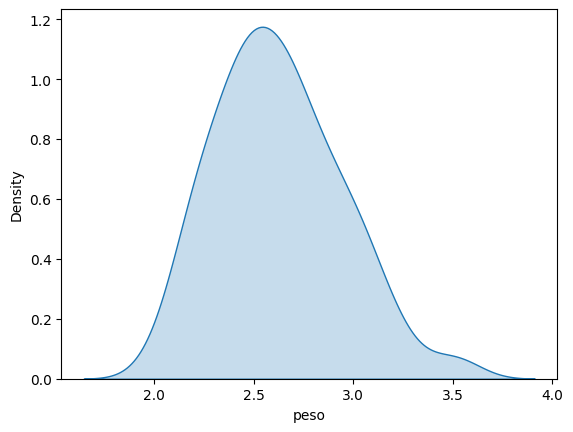

In [39]:
sns.kdeplot(data=train, x='peso', fill=True)

In [40]:
train = train.drop(columns = 'id')

In [41]:
train['peso']=train['peso'].fillna(train['peso'].mean())

In [42]:
train.isnull().sum()

,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0
longAlaAbierta,0


In [43]:
train["sexo"].value_counts()

,count
sexo,
H,57
M,37


In [44]:
numerical_cols = train.select_dtypes(include=np.number)

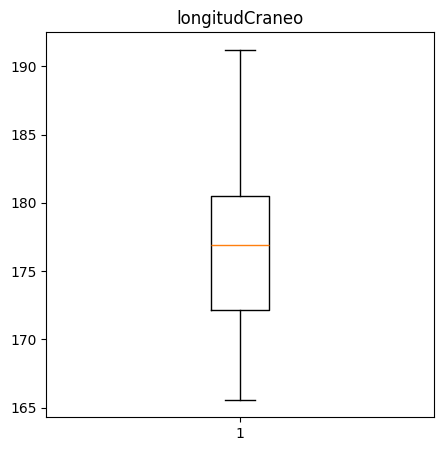

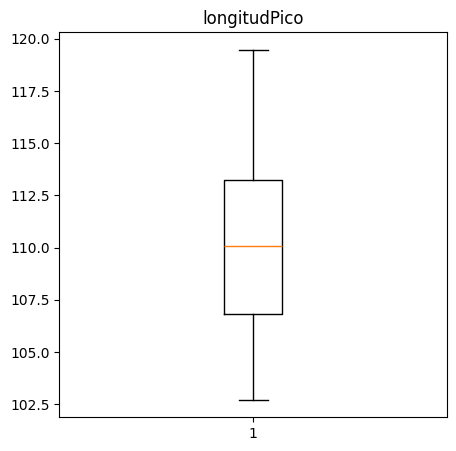

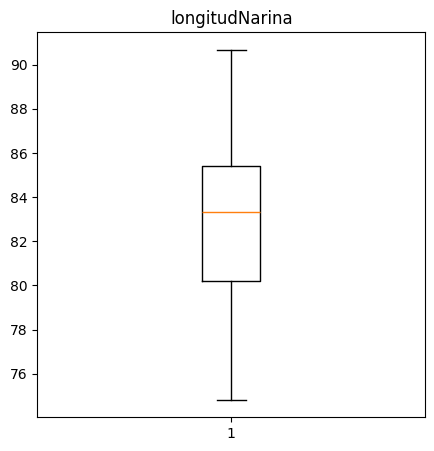

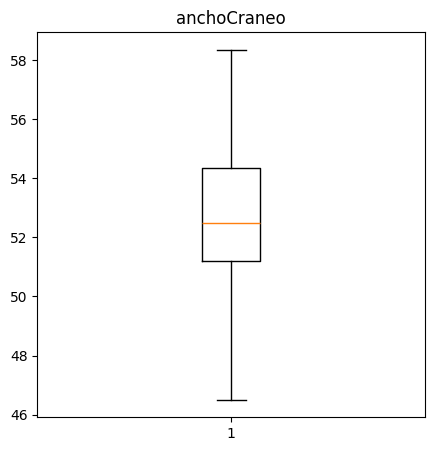

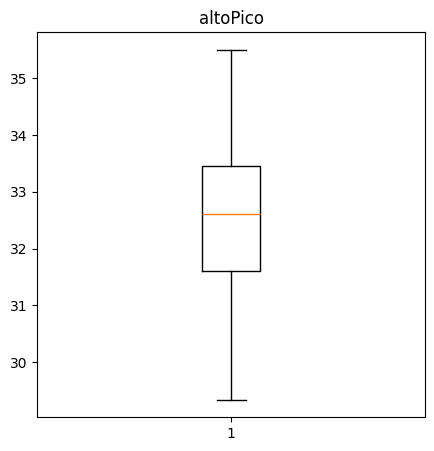

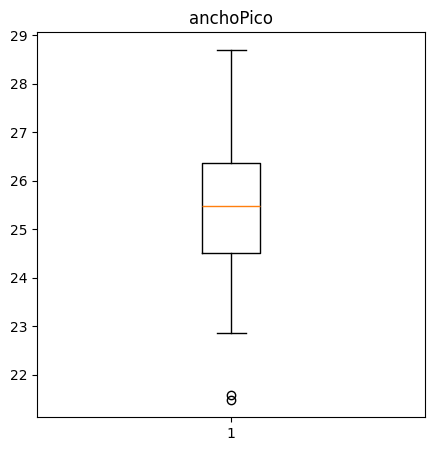

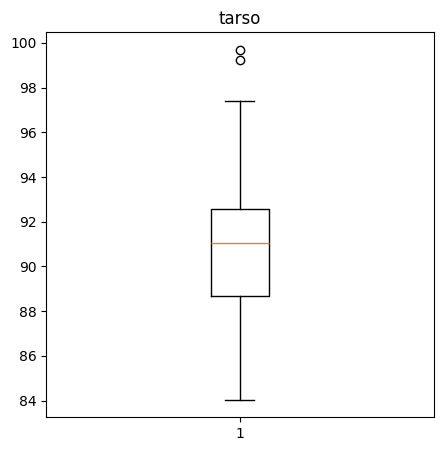

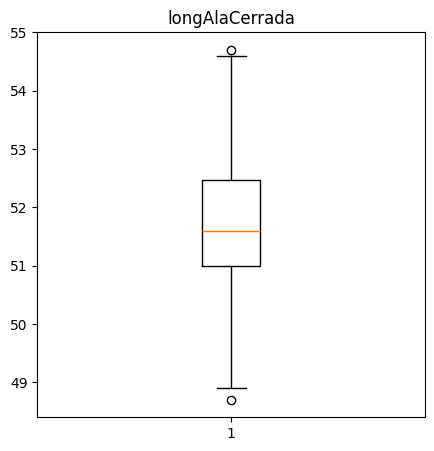

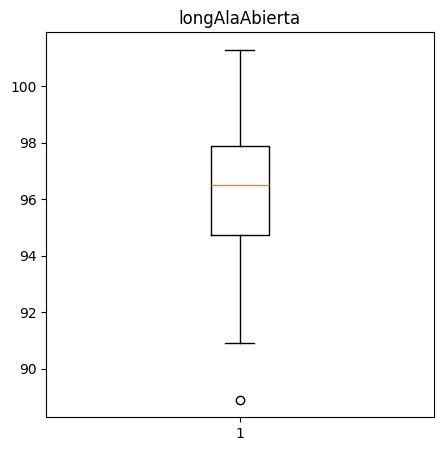

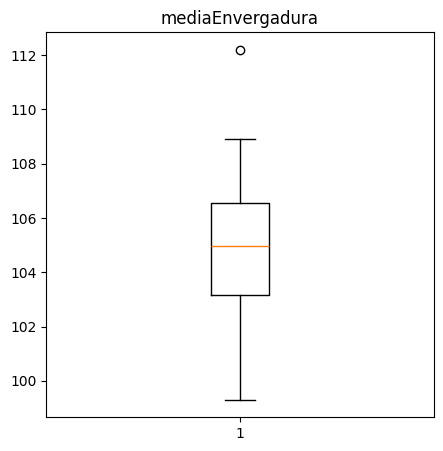

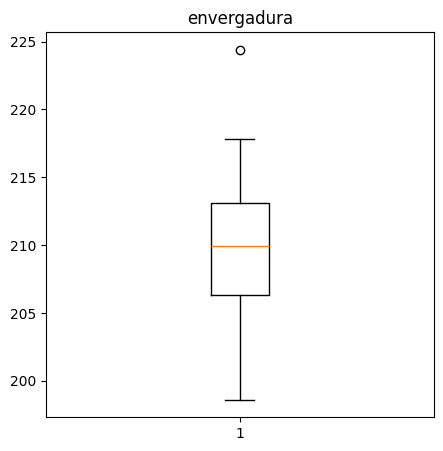

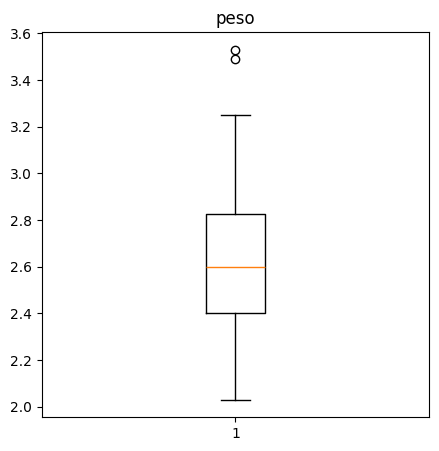

In [45]:
for i in numerical_cols:
  plt.figure(figsize=(5,5))
  plt.boxplot(train[i])
  plt.title(i)

In [47]:
for i in numerical_cols:
  Q1=train[i].quantile(0.25)
  Q3=train[i].quantile(0.75)

  IQR=Q3-Q1

  lower_boundary=Q1-1.5*IQR
  upper_boundary=Q3+1.5*IQR
  train[i] = train[i].clip(lower=lower_boundary, upper=upper_boundary)

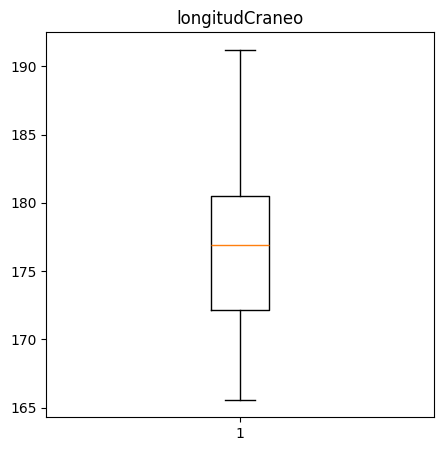

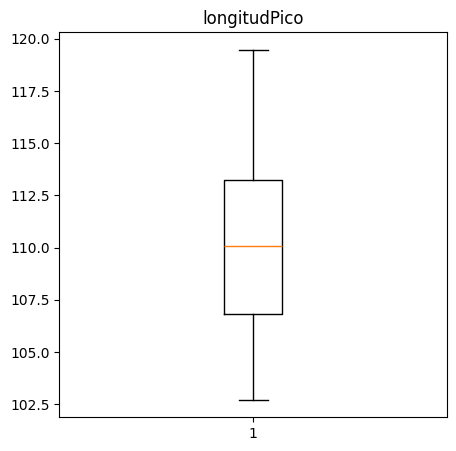

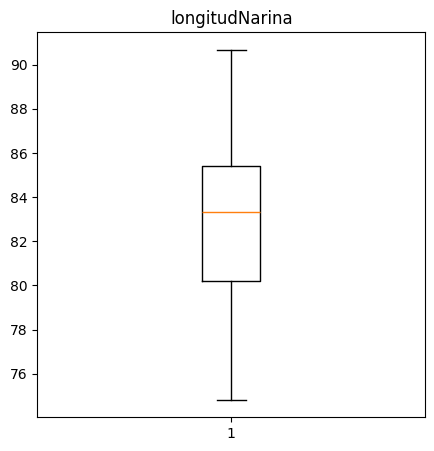

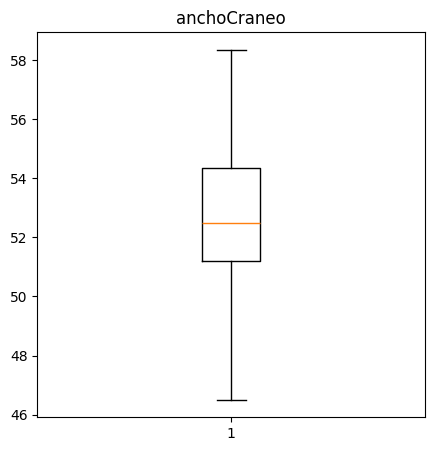

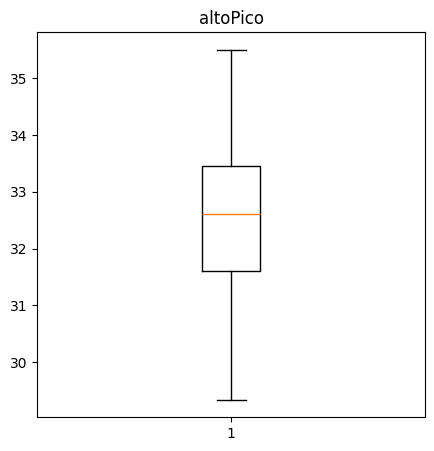

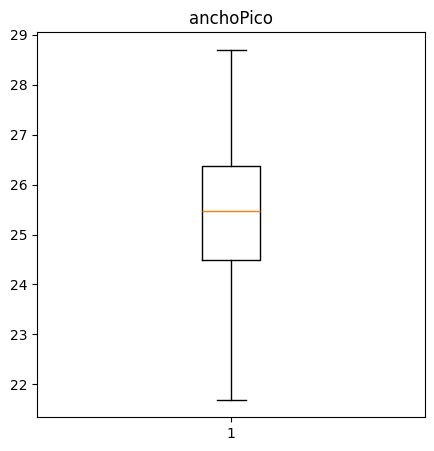

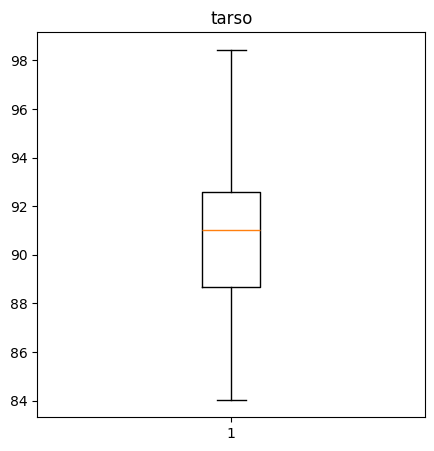

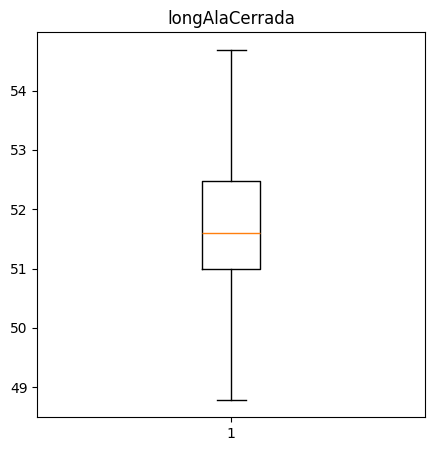

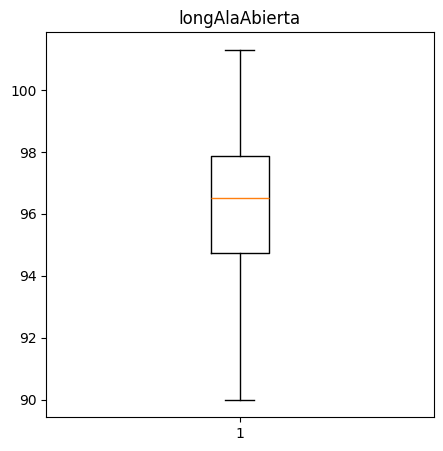

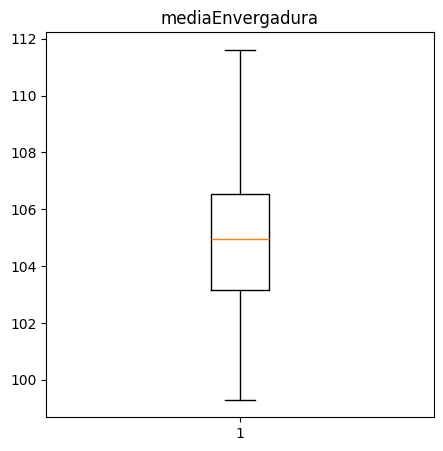

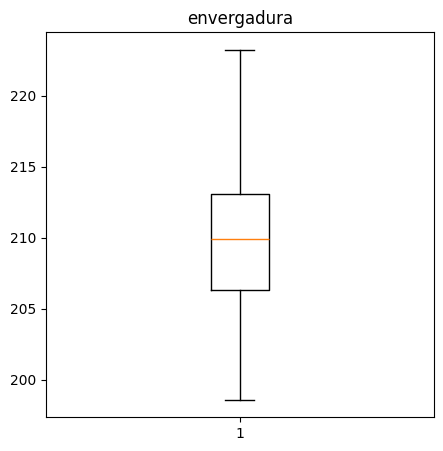

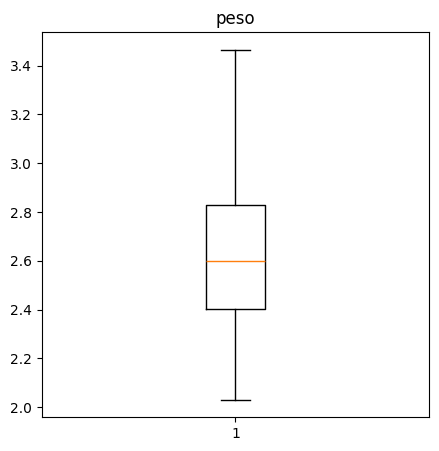

In [48]:
for i in numerical_cols:
  plt.figure(figsize=(5,5))
  plt.boxplot(train[i])
  plt.title(i)

In [49]:
X=train.drop(columns='sexo')
y=train['sexo']

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [53]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

y_train=label.fit_transform(y_train)
y_test=label.transform(y_test)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Models

####Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score, classification_report

log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)
y_pred_log=log_model.predict(X_test_scaled)


print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))

Accuracy: 0.8947368421052632
Precision: 0.8571428571428571
Recall: 0.8571428571428571
F1: 0.8571428571428571


####KNN

In [63]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
y_pred_knn=knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))

Accuracy: 0.8947368421052632
Precision: 0.8571428571428571
Recall: 0.8571428571428571
F1: 0.8571428571428571


###Decision Tree

In [66]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))

Accuracy: 0.8421052631578947
Precision: 0.8333333333333334
Recall: 0.7142857142857143
F1: 0.7692307692307693


###Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8421052631578947
Precision: 0.8333333333333334
Recall: 0.7142857142857143
F1: 0.7692307692307693


In [69]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1:", f1_score(y_test, y_pred_gb))


Accuracy: 0.8947368421052632
Precision: 0.8571428571428571
Recall: 0.8571428571428571
F1: 0.8571428571428571


In [71]:
results = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",

    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
    ]
}

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.894737,0.857143,0.857143,0.857143
1,KNN,0.894737,0.857143,0.857143,0.857143
4,Gradient Boosting,0.894737,0.857143,0.857143,0.857143
2,Decision Tree,0.842105,0.833333,0.714286,0.769231
3,Random Forest,0.842105,0.833333,0.714286,0.769231


###GridSearch CV

In [76]:


from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 13, 'knn__weights': 'uniform'}
Best CV F1 Score: 0.8958974358974361


In [77]:
best_knn = grid_search.best_estimator_

y_pred_knn_tuned = best_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn_tuned))
print("Precision:", precision_score(y_test, y_pred_knn_tuned))
print("Recall:", recall_score(y_test, y_pred_knn_tuned))
print("F1 Score:", f1_score(y_test, y_pred_knn_tuned))

Accuracy: 0.8947368421052632
Precision: 0.8571428571428571
Recall: 0.8571428571428571
F1 Score: 0.8571428571428571


In [78]:
print(classification_report(y_test, y_pred_knn_tuned))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.86      0.86      0.86         7

    accuracy                           0.89        19
   macro avg       0.89      0.89      0.89        19
weighted avg       0.89      0.89      0.89        19



In [80]:
test_ids = test["id"]
test = test.drop(columns=["id"])

In [81]:
test_predictions = best_knn.predict(test)

In [82]:
test_predictions[:10]

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [84]:
test_predictions = label.inverse_transform(test_predictions)

In [85]:
test_predictions[:10]

array(['M', 'H', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M'], dtype=object)

In [86]:
submission = pd.DataFrame({
    "id": test_ids,
    "sexo": test_predictions
})

In [87]:
submission.head()

,id,sexo
0,A70_2018,M
1,5C9_2018,H
2,5E1_2018,M
3,C58_2018,M
4,5E2_2018,M


In [88]:
submission["sexo"].value_counts()

,count
sexo,
M,23
H,18


In [89]:
submission.to_csv("submission.csv",index=False)